Chebyshev Economization by Subtracting a Chebyshev Polynomial
=================================================================

*Burden & Faires, Numerical Analysis* (§8, “Chebyshev Economization”) reduces
a high‑degree **Taylor** series by *subtracting* a suitably scaled Chebyshev
polynomial of the same degree.  Doing so removes the highest‑degree power‑term
while keeping the oscillatory error almost uniform on [-1, 1].

This notebook walks through **one economization step** for  

\[
f(x)=e^{x}, \quad x\in[-1,1].
\]

You can repeat the step to drop the degree further.


In [24]:
import numpy as np
from scipy.special import factorial
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial, Chebyshev

%matplotlib inline


In [10]:
def taylor_coeffs_exp(m):
    """Return coefficients of the degree‑m Maclaurin (Taylor) poly for e^x."""
    return [1/factorial(k) for k in range(m+1)]

def economize_once(power_coeffs):
    """Subtract the Chebyshev polynomial of the *same* degree to drop one degree.

    Parameters
    ----------
    power_coeffs : list[float]
        Power‑basis coeffs of a degree‑m polynomial p(x)=Σ c_k x^k.

    Returns
    -------
    new_coeffs : np.ndarray
        Power‑basis coeffs of degree‑(m‑1) economized polynomial.
    scale      : float
        The scale factor α that multiplies T_m.
    """
    m = len(power_coeffs) - 1
    c_m = power_coeffs[-1]

    # Chebyshev T_m has leading term 2^{m−1} x^m
    leading_cheb = 2**(m-1)
    alpha = c_m / leading_cheb          # amount to subtract

    # Build α * T_m in power basis
    Tm = Chebyshev.basis(m)             # coefficient [0,…,0,1] in Chebyshev basis
    alpha_Tm_power = (alpha * Tm).convert(kind=Polynomial)

    # Subtract
    P = Polynomial(power_coeffs)
    E = P - alpha_Tm_power
    # Trim possible tiny trailing coeff
    Ecoef = E.coef[:-1]                 # drop last since degree reduced
    return np.array(Ecoef), alpha


In [25]:
# Settings
m_high = 8              # Taylor degree
power_coeffs = taylor_coeffs_exp(m_high)

# First economization step
econ_coeffs, alpha = economize_once(power_coeffs)

print(f"Leading Taylor coeff c_{m_high} = {power_coeffs[-1]:.3e}")
print(f"α (scale for T_{m_high}) = {alpha:.3e}")


Leading Taylor coeff c_8 = 2.480e-05
α (scale for T_8) = 1.938e-07


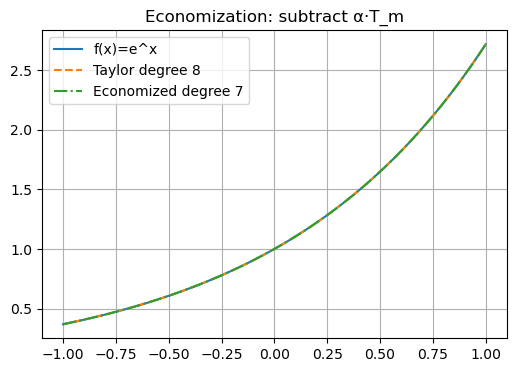

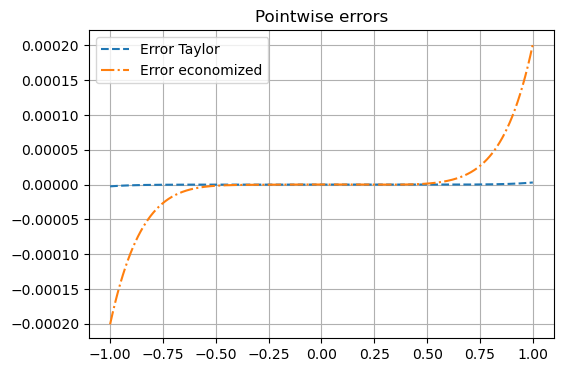

Max |error| Taylor degree 8:      3.06e-06
Max |error| Economized degree 7: 2.02e-04


In [27]:
# Build polynomials
P_taylor = Polynomial(power_coeffs)
P_econ   = Polynomial(econ_coeffs)

# Evaluation grid
x = np.linspace(-1, 1, 500)
f = np.exp(x)
y_taylor = P_taylor(x)
y_econ   = P_econ(x)

# Plot approximations
plt.figure(figsize=(6,4))
plt.plot(x, f, label='f(x)=e^x')
plt.plot(x, y_taylor, '--', label=f'Taylor degree {m_high}')
plt.plot(x, y_econ, '-.', label=f'Economized degree {m_high-1}')
plt.legend()
plt.grid(True)
plt.title('Economization: subtract α·T_m')
plt.show()

# Error comparison
plt.figure(figsize=(6,4))
plt.plot(x, f - y_taylor, '--', label='Error Taylor')
plt.plot(x, f - y_econ,  '-.', label='Error economized')
plt.legend()
plt.grid(True)
plt.title('Pointwise errors')
plt.show()

print(f"Max |error| Taylor degree {m_high}:      {np.max(np.abs(f-y_taylor)):.2e}")
print(f"Max |error| Economized degree {m_high-1}: {np.max(np.abs(f-y_econ)):.2e}")


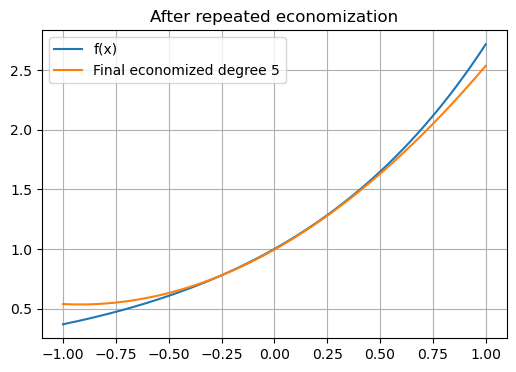

Max |error| after repeated economization to degree 5: 1.81e-01


In [28]:
# Repeat to drop to degree 4 (optional demonstration)
target_degree = 5
current_coeffs = power_coeffs.copy()
current_degree = m_high

while current_degree > target_degree:
    current_coeffs, alpha = economize_once(current_coeffs)
    current_degree -= 1

P_final = Polynomial(current_coeffs)
y_final = P_final(x)

plt.figure(figsize=(6,4))
plt.plot(x, f, label='f(x)')
plt.plot(x, y_final, label=f'Final economized degree {target_degree}')
plt.legend(); plt.grid(True)
plt.title('After repeated economization')
plt.show()

print(f"Max |error| after repeated economization to degree {target_degree}: {np.max(np.abs(f - y_final)):.2e}")


How It Works
------------

* A Taylor polynomial’s leading term gives a large end‑point error on [-1, 1].
* **T_m(x)** has the same leading power term but oscillates between ±1,
  so subtracting **α T_m** removes the x^m term and spreads the error.
* Repeating the step successively removes the highest power while keeping the
  near‑minimax property of Chebyshev polynomials.

Adjust `m_high` and `target_degree` above to explore further.


*Notebook generated 2025-06-16.*